In [31]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
import seaborn as sns
import os
import pandas as pd
import pickle
from PcmPy.sim import make_signal
from OptimalBattery.plot import plot_correlations
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
from matplotlib.colors import ListedColormap, to_rgb


# start with some U_true and make it arrange.logpi

In [32]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25
theta_mu = 100

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [33]:
base_colors = ['red', 'green', 'blue', 'orange', 'purple']
cmap_list = []
for color in base_colors:
    base_rgb = np.array(to_rgb(color))
    for i in range(K_subparcels):
        factor = 0.6 + 0.4 * (i / (K_subparcels - 1))
        shade_rgb = base_rgb * factor + (1 - factor) * np.ones(3)
        cmap_list.append(shade_rgb)

custom_cmap = ListedColormap(cmap_list)

In [34]:
# Compute positions of all pixels
X_coords, Y_coords = np.meshgrid(np.arange(width), np.arange(height), indexing='ij')
X_coords = X_coords.flatten()
Y_coords = Y_coords.flatten()
positions = np.column_stack((X_coords, Y_coords))

# Compute distances from pixel to each centroid
D = np.zeros((grid.P, K_main))
for k, (cx, cy) in enumerate(centroids):
    D[:, k] = np.sqrt((X_coords - cx)**2 + (Y_coords - cy)**2)

# Initialize the parcel labels and define the size of each parcel
parcel_labels = np.full(grid.P, -1, dtype=int)
unassigned_nodes = set(range(grid.P))
desired_size = grid.P // K_main

for k in range(K_main - 1):
    unassigned_nodes_list = list(unassigned_nodes)
    distances = D[unassigned_nodes_list, k]
    sorted_indices = np.argsort(distances)
    nodes_to_assign = np.array(unassigned_nodes_list)[sorted_indices[:desired_size]]
    parcel_labels[nodes_to_assign] = k
    unassigned_nodes -= set(nodes_to_assign)

# Assign the remaining pixels to the last parcel
parcel_labels[list(unassigned_nodes)] = K_main - 1


# Initialize new parcel labels
new_parcel_labels = np.full(grid.P, -1, dtype=int)

for k in range(K_main):  # For each main parcel
    nodes_in_parcel = np.where(parcel_labels == k)[0]
    # Split nodes_in_parcel into K_subparcels of equal size
    subparcel_nodes = np.array_split(nodes_in_parcel, K_subparcels)
    for sub_k, nodes in enumerate(subparcel_nodes):
        new_parcel_label = k * K_subparcels + sub_k
        new_parcel_labels[nodes] = new_parcel_label

# Convert new parcel labels to a matrix U_true
U_true = np.zeros((K_total, grid.P))
for k in range(K_total):
    U_true[k, new_parcel_labels == k] = 1

# Convert U_true to torch tensor
U_true = pt.tensor(U_true, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true)


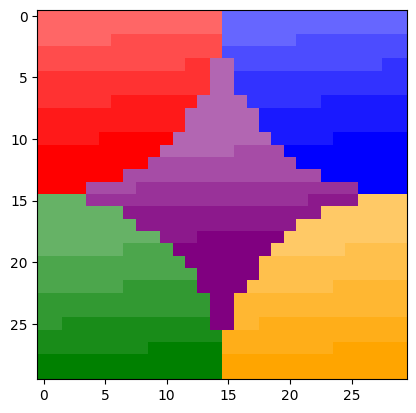

In [35]:
parcel_labels_plot = U_true.argmax(dim=0).numpy()
parcel_labels_plot = parcel_labels_plot.reshape((height, width))
plt.imshow(parcel_labels_plot, cmap=custom_cmap)

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

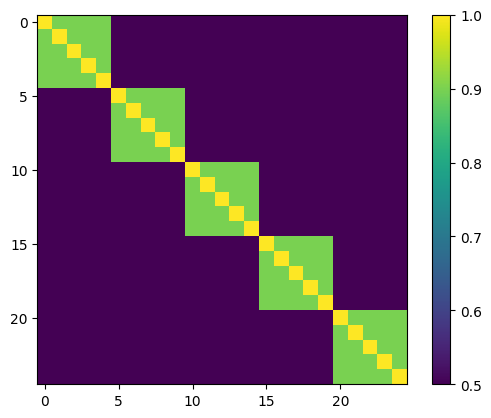

In [36]:
K_total = 25
group_size = 5
base_correlation = 0.5  
extra_correlation = 0.4 

R = np.full((K_total, K_total), base_correlation)
for i in range(0, K_total, group_size):
    R[i:i+group_size, i:i+group_size] = base_correlation + extra_correlation

np.fill_diagonal(R, 1)

plt.imshow(R)
plt.colorbar()
plt.show()


covariance across tasks G

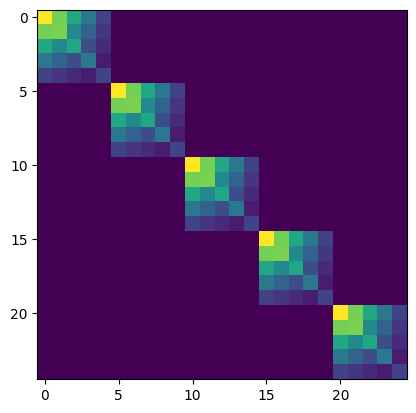

In [37]:
def custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.0004, variance_factors=[1.0, 0.75, 0.5, 0.25]):
    G = np.zeros((n_tasks, n_tasks))
    task_index = 0

    for group in range(n_groups):
        variances = variance_factors

        # Compute covariances based on desired correlation
        covariances = target_corr * np.outer(variance_factors, variance_factors)
        np.fill_diagonal(covariances, variances)

        # Place the block into G
        start, end = task_index, task_index + group_size
        G[start:end, start:end] = covariances

        task_index += group_size

    return G
G = custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=[1.0, 0.8,0.6, 0.4, 0.2])
plt.imshow(G)

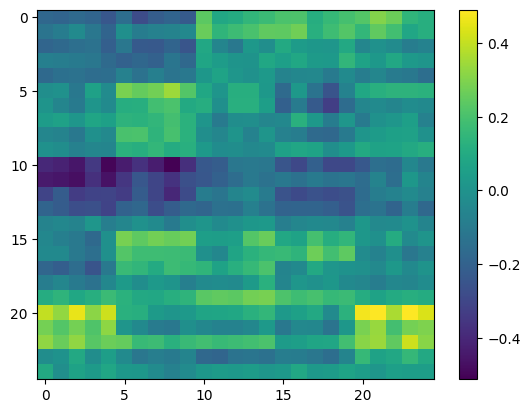

In [38]:
Vs= sim.random_matrix_normal(G=G, R=R, make_exact=True, rng=np.random.default_rng(8))
Vs = pt.tensor(Vs, dtype=pt.float32)

plt.imshow(Vs, aspect='auto', cmap='viridis')
plt.colorbar()
plt.show()


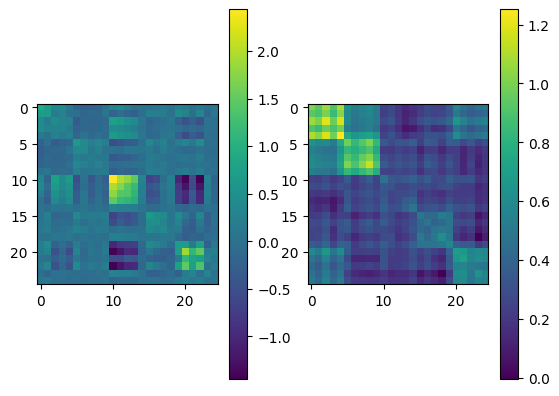

In [39]:
# make subplots and plot Vs @ Vs.T and Vs.T @ Vs
plt.subplot(1, 2, 1)
plt.imshow(Vs @ Vs.T, cmap='viridis')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(Vs.T @ Vs, cmap='viridis')
plt.colorbar()
plt.show()


In [41]:
Y_true = Vs @ U_true
# Y_noisy= Y_true + pt.randn_like(Y_true) * 0.1
Y_noisy= Y_true


Y_test = Y_true[:, :]
# Y_test_noisy = Y_test + pt.randn_like(Y_test) * 0.1
Y_test_noisy = Y_test

vtest = Vs[:, :]

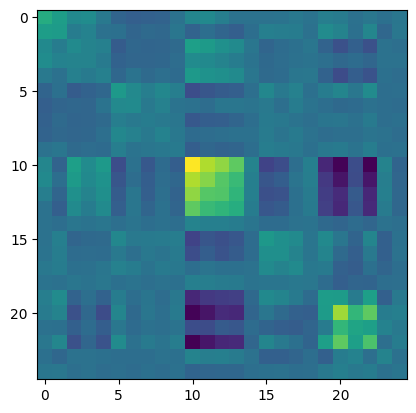

In [42]:
G_lib  = Y_noisy @ Y_noisy.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

In [43]:
offsets = [1e-6,1e-4,1e-2,1,1e2,1e4,1e6]

In [46]:
D = ut.build_combinations(G_lib, strategy='random',offs = offsets,n_iter=10000,n_tasks=8,seed=408)



building0


In [47]:
def evaluate_combinations(D, YLib,VLib, ytest, vtest, U_true_region):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    mse_ols_dict = {}
    cos_ols_dict = {}

    ytest = pt.tensor(ytest,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)
    U_true_region = U_true_region.numpy()
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        if i % 100 == 0:
            print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = VLib[task_subset_indices,:]

        y_subset = YLib[task_subset_indices, :]
        y_subset = y_subset - y_subset.mean(axis=0)

        #tensors to np
        y_subset = y_subset.numpy()
        V_subset = V_subset.numpy()
        
        
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        mse_ols = sim.U_MSE(U_true_region, U_hat_ols[:,:])
        
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols[:,:]).mean().cpu().numpy()
        cos_ols = cos_ols.item()
        
        # Store the result in the dictionary
        mse_ols_dict[comb_tuple] = mse_ols
        cos_ols_dict[comb_tuple] = cos_ols
    
    # Map the computed cos_HBP values back to the DataFrame
    D['mse_ols'] = D['combination_tuple'].map(mse_ols_dict)
    D['cos_ols'] = D['combination_tuple'].map(cos_ols_dict)
    
    return D

In [48]:
D = evaluate_combinations(D, Y_noisy, Vs, Y_test_noisy, vtest, U_true[:, :])

/tmp/ipykernel_103943/256261657.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest,dtype=pt.float32)
/tmp/ipykernel_103943/256261657.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest,dtype=pt.float32)


Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 34

In [75]:
D_specific_offset = D
# inclode only rows with mse_ols < 1
D_specific_offset = D_specific_offset[D_specific_offset['mse_ols'] < 0.3]
len(D_specific_offset)

3220

In [77]:
pearsonr(D_specific_offset['max_var'], D_specific_offset['mse_ols'])

PearsonRResult(statistic=-1.521155516052931e-07, pvalue=0.9999931154911578)

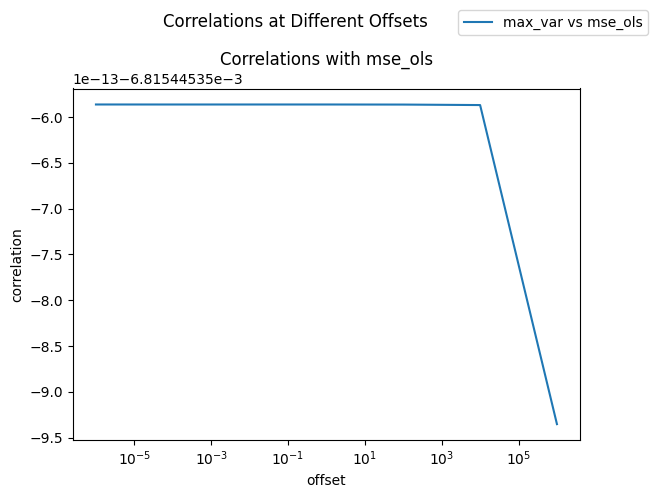

In [76]:
plot_correlations(D_specific_offset,['max_var'],['mse_ols'])